EDA for the spacex_launches file


Possible features to use

- [rocket_name,launchpad_id,launchpad_name,success,failures,crew_count,payloads_count,cores_reused,landing_success,landing_type]

- Plots:
    - Success Distribution
    - Covariance and correlation of the raw data to see if any features are related to each other
    - Scatter plots and histograms for the features


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np

PROJECT_ROOT = Path().cwd().parent
# FILE_PATH = PROJECT_ROOT / "data" / "raw" / "spacex_launches.csv"

FILE_PATH = PROJECT_ROOT / "data" / "processed" / "processed_data.csv"

ROCKETS_FILE_PATH = PROJECT_ROOT / "data" / "raw" / "spacex_rockets.csv"



success
1    181
0      5
Name: count, dtype: int64


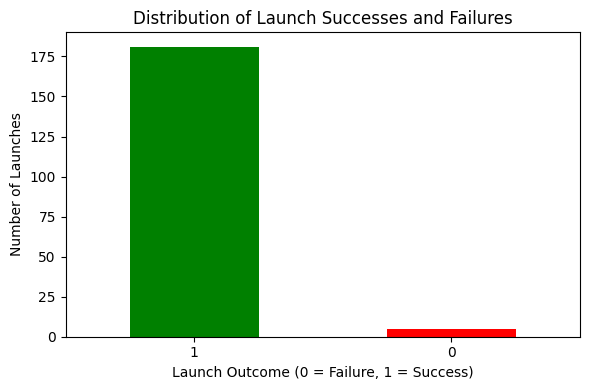

In [9]:
#
df = pd.read_csv(FILE_PATH)
print(df['success'].value_counts())
# Sucess distribution
success_counts = df['success'].value_counts()
plt.figure(figsize=(6, 4))
success_counts.plot(kind='bar', color=['green', 'red'])
plt.title('Distribution of Launch Successes and Failures')
plt.xlabel('Launch Outcome (0 = Failure, 1 = Success)')
plt.ylabel('Number of Launches')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


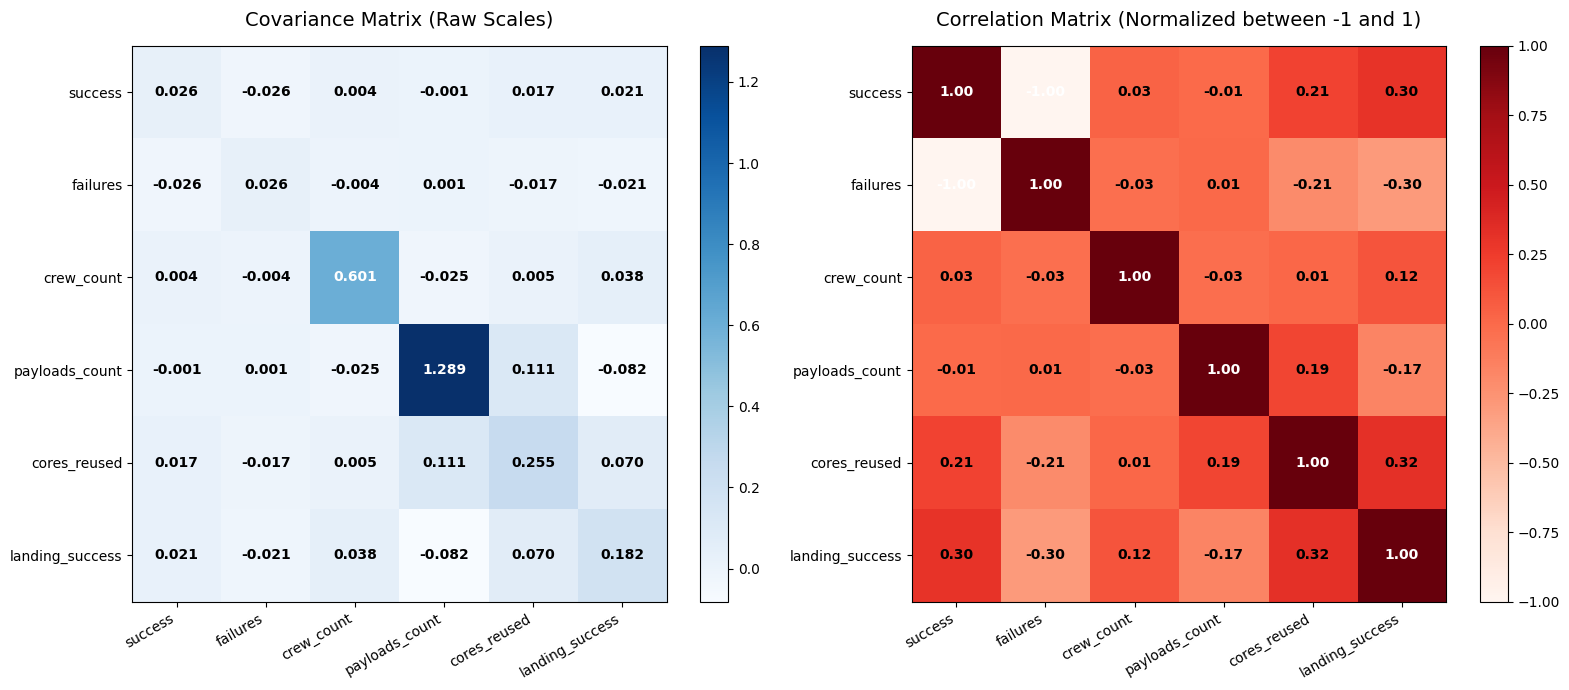

In [10]:
features = ['success', 'failures', 'crew_count', 'payloads_count', 'cores_reused', 'landing_success']


cov_matrix = df[features].cov()
corr_matrix = df[features].corr()


fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
cax1 = ax.imshow(cov_matrix.values, cmap = 'Blues',aspect='auto')
ax.set_title('Covariance Matrix (Raw Scales)', fontsize=14, pad=15)
ax.set_xticks(np.arange(len(features)))
ax.set_xticklabels(features, rotation=30, ha='right')
ax.set_yticks(np.arange(len(features)))
ax.set_yticklabels(features)
fig.colorbar(cax1, ax=ax)

for (j, i), val in np.ndenumerate(cov_matrix.values):
    text_color = 'white' if abs(val) > 0.6 else 'black'
    ax.text(i, j, f"{val:.3f}", ha='center', va='center', color=text_color, fontweight='bold')

ax = axes[1]
cax2 = ax.imshow(corr_matrix.values, cmap = 'Reds', aspect='auto', vmin=-1, vmax=1)
ax.set_title('Correlation Matrix (Normalized between -1 and 1)', fontsize=14, pad=15)
ax.set_xticks(np.arange(len(features)))
ax.set_xticklabels(features, rotation=30, ha='right')
ax.set_yticks(np.arange(len(features)))
ax.set_yticklabels(features)
fig.colorbar(cax2, ax=ax)

for (j, i), val in np.ndenumerate(corr_matrix.values):
    text_color = 'white' if abs(val) > 0.5 else 'black'
    ax.text(i, j, f"{val:.2f}", ha='center', va='center', color=text_color, fontweight='bold')

plt.tight_layout()
plt.show()

- Pairs with relatively better corr vals:
    - success and landing_success (There are no failed missions after a landing success/ does it make sense to use??)
    - success and cores_reused
    - success and failures (mission success vs number of launch failures)
    - cores_reused and landing_success

- Most of the features don't seem to be linearly related to a large extent


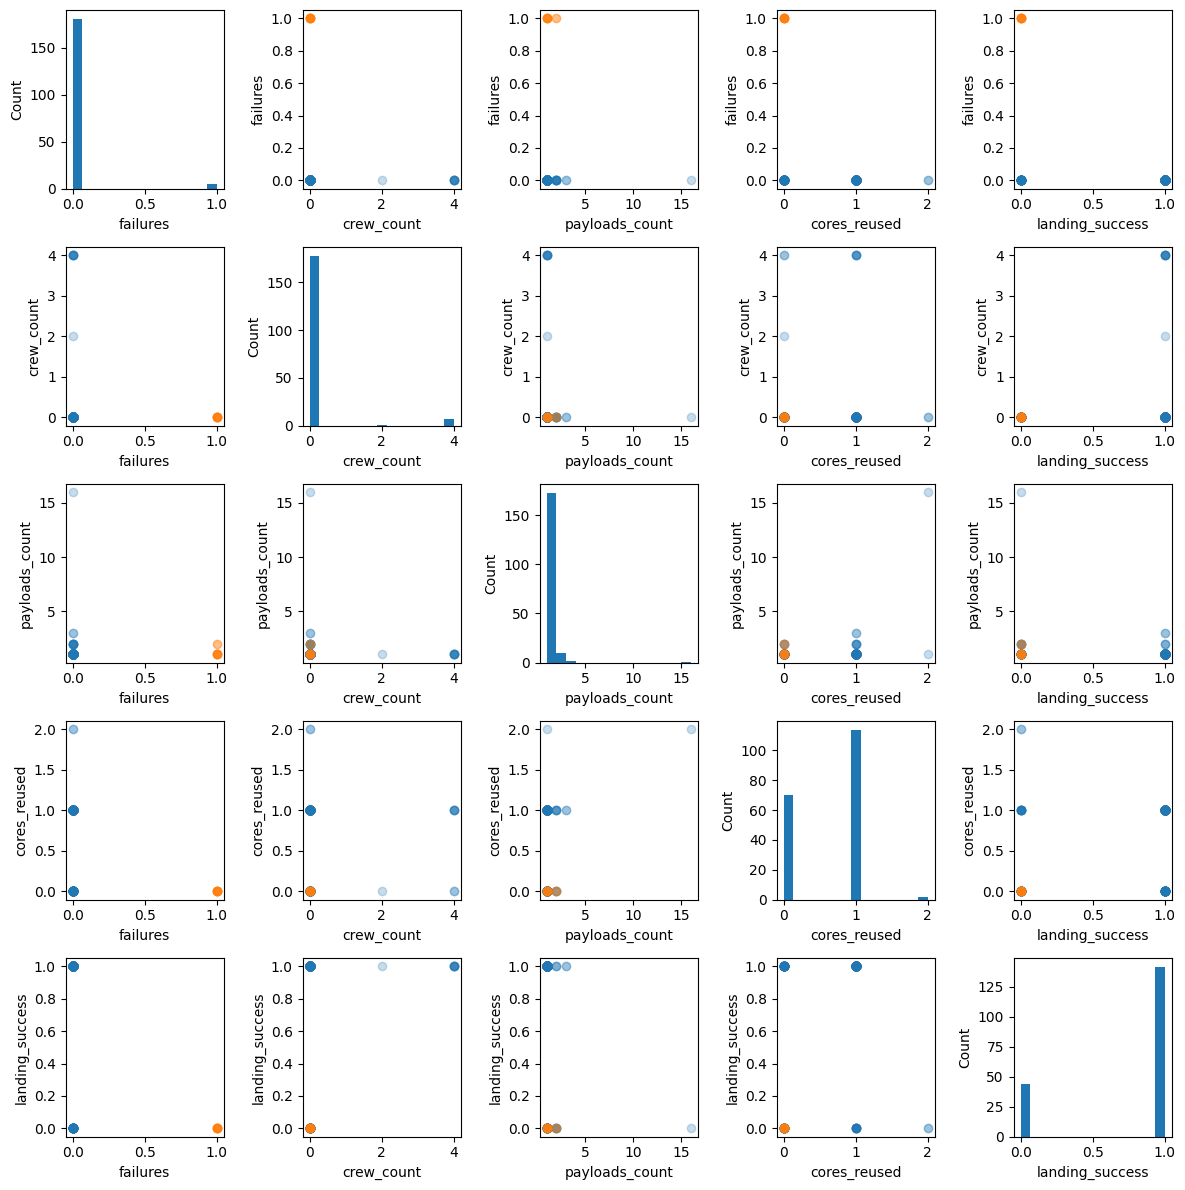

success  failures
0        1             5
1        0           181
Name: count, dtype: int64


In [11]:
import matplotlib.pyplot as plt

variables = [
    "failures",
    "crew_count",
    "payloads_count",
    "cores_reused",
    "landing_success"
]

n = len(variables)
fig, axes = plt.subplots(n, n, figsize=(12,12))

for i in range(n):
    for j in range(n):
        x = variables[j]
        y = variables[i]
        ax = axes[i, j]
        if i == j:

            ax.hist(df[x].dropna(), bins=15)

            ax.set_xlabel(x)
            ax.set_ylabel("Count")

        else:

            success = df[df["success"] == 1]
            failure = df[df["success"] == 0]

            ax.scatter(
                success[x],
                success[y],
                alpha=0.25,
                label="Success"
            )

            ax.scatter(
                failure[x],
                failure[y],
                alpha=0.5,
                label="Failure"
            )

            ax.set_xlabel(x)
            ax.set_ylabel(y)

plt.tight_layout()

plt.show()

print(df.groupby("success")["failures"].value_counts())

## My takeaways from this

1. Most launches have 0 failures

2. Crew missions are rare very few missions with 2-4 people
    - Too few crew missions to generalize anything (I personally doubt this var would have any impact)
    - They seem to be pretty successful when checking the mission success vs num of failures

3. Payload Count has 1 high value at 16. The rest of them are around 0-3 (Seems highly skewed)

4. cores_reused vs landing success/failures
    - reused cores still appear with successful launches
    - no obvious signs of failures at higher reuse

5. Small dataset with repeated points/few variations or unique combinations
    - We are most likely gonna have to do cross validation
    - Since many points overlap, focus on feature engineering(?)


**Logistic Regression (?)**

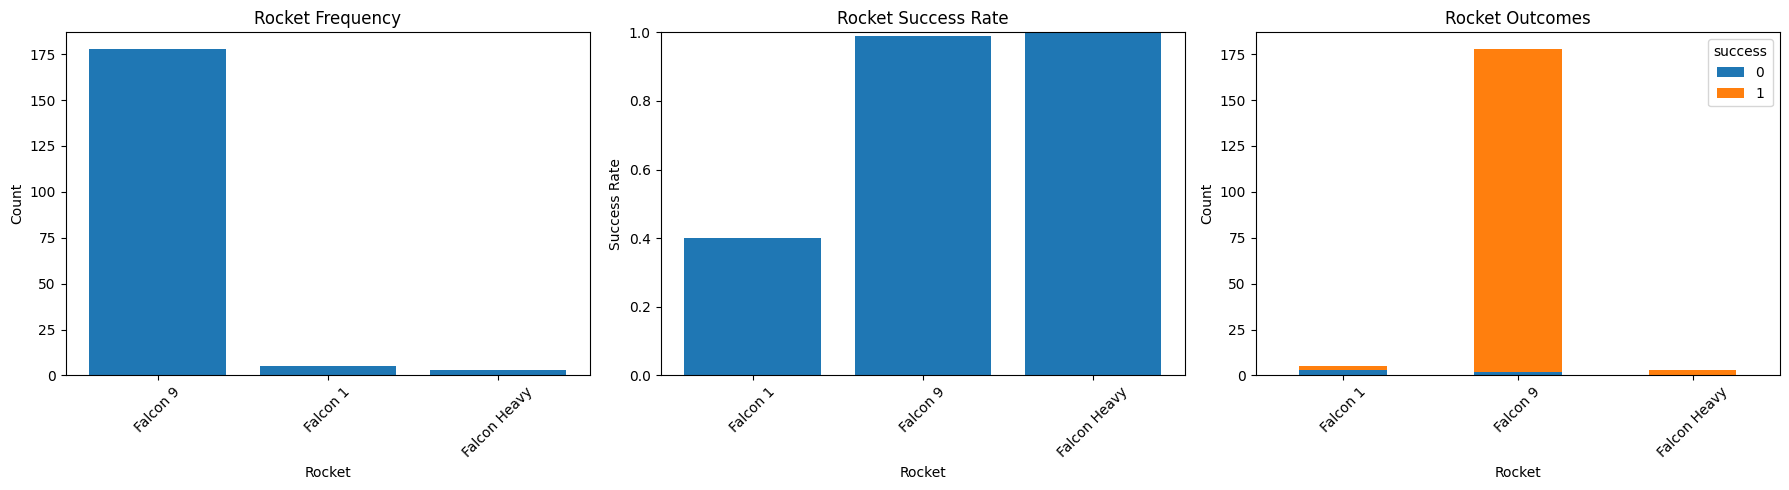

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18,5))


rocket_counts = df["rocket_name"].value_counts()

axes[0].bar(
    rocket_counts.index,
    rocket_counts.values
)

axes[0].set_title("Rocket Frequency")
axes[0].set_xlabel("Rocket")
axes[0].set_ylabel("Count")

axes[0].tick_params(axis="x", rotation=45)

rocket_success = df.groupby(
    "rocket_name"
)["success"].mean()

axes[1].bar(
    rocket_success.index,
    rocket_success.values
)

axes[1].set_title("Rocket Success Rate")
axes[1].set_xlabel("Rocket")
axes[1].set_ylabel("Success Rate")

axes[1].set_ylim(0,1)

axes[1].tick_params(axis="x", rotation=45)

rocket_outcomes = df.groupby(
    ["rocket_name", "success"]
).size().unstack(fill_value=0)

rocket_outcomes.plot(
    kind="bar",
    stacked=True,
    ax=axes[2]
)

axes[2].set_title("Rocket Outcomes")
axes[2].set_xlabel("Rocket")
axes[2].set_ylabel("Count")

axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

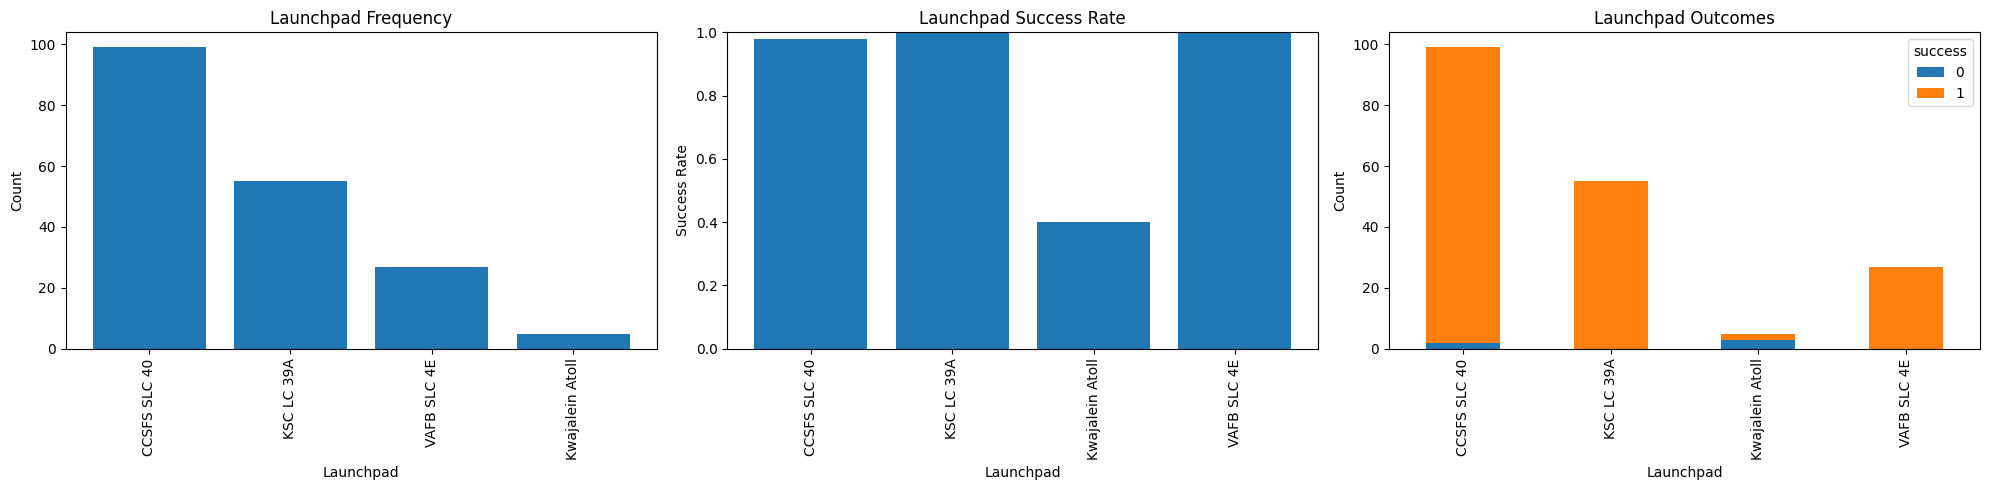

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20,5))

launchpad_counts = df["launchpad_name"].value_counts()

axes[0].bar(
    launchpad_counts.index,
    launchpad_counts.values
)

axes[0].set_title("Launchpad Frequency")
axes[0].set_xlabel("Launchpad")
axes[0].set_ylabel("Count")

axes[0].tick_params(axis="x", rotation=90)

launchpad_success = df.groupby(
    "launchpad_name"
)["success"].mean()

axes[1].bar(
    launchpad_success.index,
    launchpad_success.values
)

axes[1].set_title("Launchpad Success Rate")
axes[1].set_xlabel("Launchpad")
axes[1].set_ylabel("Success Rate")

axes[1].set_ylim(0,1)

axes[1].tick_params(axis="x", rotation=90)

launchpad_outcomes = df.groupby(
    ["launchpad_name", "success"]
).size().unstack(fill_value=0)

launchpad_outcomes.plot(
    kind="bar",
    stacked=True,
    ax=axes[2]
)

axes[2].set_title("Launchpad Outcomes")
axes[2].set_xlabel("Launchpad")
axes[2].set_ylabel("Count")

axes[2].tick_params(axis="x", rotation=90)

plt.tight_layout()
plt.show()

KeyError: 'landing_type'

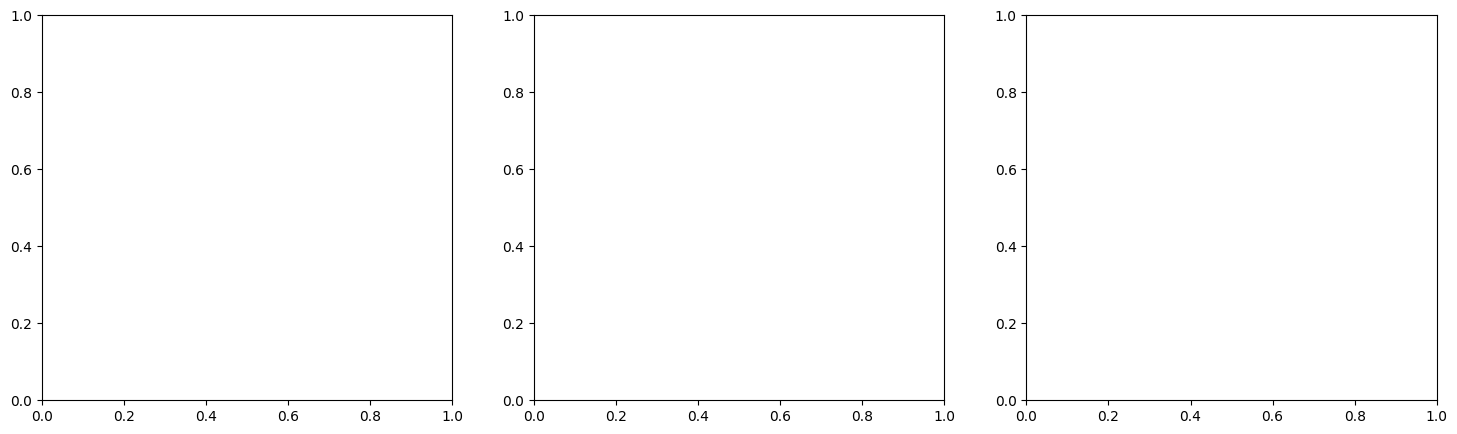

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))

landing_counts = df["landing_type"].value_counts()

axes[0].bar(
    landing_counts.index,
    landing_counts.values
)

axes[0].set_title("Landing Type Frequency")
axes[0].set_xlabel("Landing Type")
axes[0].set_ylabel("Count")

axes[0].tick_params(axis="x", rotation=45)

landing_success = df.groupby(
    "landing_type"
)["success"].mean()

axes[1].bar(
    landing_success.index,
    landing_success.values
)

axes[1].set_title("Landing Type Success Rate")
axes[1].set_xlabel("Landing Type")
axes[1].set_ylabel("Success Rate")

axes[1].set_ylim(0,1)

axes[1].tick_params(axis="x", rotation=45)

landing_outcomes = df.groupby(
    ["landing_type", "success"]
).size().unstack(fill_value=0)

landing_outcomes.plot(
    kind="bar",
    stacked=True,
    ax=axes[2]
)

axes[2].set_title("Landing Type Outcomes")
axes[2].set_xlabel("Landing Type")
axes[2].set_ylabel("Count")

axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()